# From character prediction to context windows

The previous project asked a very small question: **given one character, what character is likely to come next?** That is a bigram model, written as

\[P(c_{t+1} \mid c_t).\]

It can learn that `q` is usually followed by `u`, but it cannot use the characters before `q`, or the beginning of the word that contains it. This notebook widens the visible context to four characters and asks what changes.

The goal is not to make a strong language model. The goal is to make the next modeling step precise: text becomes overlapping context-target examples, those examples become tensors with shape `(batch, context_length)`, and a small PyTorch network maps each context to next-character logits.

## What we will establish

By the end, we will have measured four things:

1. How a character stream becomes examples such as `"the " → "q"`.
2. Why the same sequence can be arranged into a batch with shape `(batch, time)`.
3. How a feed-forward model uses all four character positions and improves on a one-character bigram baseline.
4. What this fixed context model still cannot do, and why attention is the natural next question.

The split is chronological within each book. The validation portion is later text, so neighboring characters from the same passage are not randomly mixed between training and validation.

In [1]:
from ast import literal_eval
import math
import random

import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset
from torch import nn
from torch.nn import functional as F

SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cpu


## 1. Reuse the small, documented corpus

We keep the same two public-domain books as the character-level project. The dataset is downloaded on the first run through Hugging Face `datasets`; later runs use its local cache. Restricting the selection here makes the experiment small enough to inspect and keeps the comparison with the bigram notebook meaningful.

In [2]:
DATASET_NAME = "stas/gutenberg-100"
BOOK_TITLES = {
    "Frankenstein; Or, The Modern Prometheus",
    "The Time Machine",
}

def decode_dataset_text(value):
    """Convert the dataset field to an ordinary Python string."""
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace")
    if isinstance(value, str) and value.startswith("b'"):
        return literal_eval(value).decode("utf-8", errors="replace")
    return str(value)

def remove_gutenberg_wrapper(text):
    """Remove standard Project Gutenberg metadata when it is present."""
    start_marker, end_marker = "*** START OF", "*** END OF"
    start, end = text.find(start_marker), text.find(end_marker)
    if 0 <= start < end:
        text = text[text.find("\n", start) + 1 : end]
    return text

def clean_book(text):
    """Normalize line endings and preserve prose, spaces, and paragraph breaks."""
    text = remove_gutenberg_wrapper(text)
    return text.replace("\r\n", "\n").replace("\r", "\n").strip()

records = load_dataset(DATASET_NAME, split="train")
books = {}
for record in records:
    title = record["title"].strip("'\"")
    if title in BOOK_TITLES:
        books[title] = clean_book(decode_dataset_text(record["text"]))
    if len(books) == len(BOOK_TITLES):
        break

missing_titles = BOOK_TITLES - books.keys()
if missing_titles:
    raise RuntimeError(f"Missing requested books: {sorted(missing_titles)}")

for title in sorted(books):
    print(f"{title}: {len(books[title]):,} characters")

'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/datasets/stas/gutenberg-100/resolve/23209fe8d595664bd9c555f8e0305bd16d4ff437/gutenberg-100.py


Retrying in 1s [Retry 1/5].


'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/datasets/stas/gutenberg-100/resolve/23209fe8d595664bd9c555f8e0305bd16d4ff437/gutenberg-100.py


Retrying in 2s [Retry 2/5].


'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/datasets/stas/gutenberg-100/resolve/23209fe8d595664bd9c555f8e0305bd16d4ff437/gutenberg-100.py


...

Retrying in 8s [Retry 5/5].


'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/datasets/stas/gutenberg-100/resolve/23209fe8d595664bd9c555f8e0305bd16d4ff437/gutenberg-100.py


Using the latest cached version of the dataset since stas/gutenberg-100 couldn't be found on the Hugging Face Hub


Found the latest cached dataset configuration 'default' at /Users/oasis/.cache/huggingface/datasets/stas___gutenberg-100/default/0.0.0/23209fe8d595664bd9c555f8e0305bd16d4ff437 (last modified on Sun Sep 27 06:35:25 2026).


Frankenstein; Or, The Modern Prometheus: 438,269 characters
The Time Machine: 179,692 characters


## 2. Split first, then encode

Each book is split at 90 percent of its length. We do this before constructing context windows. That matters: if we built windows across the split, a training example could accidentally use validation characters as its target or context.

In [3]:
train_texts, validation_texts = {}, {}
for title, text in books.items():
    split_at = int(0.90 * len(text))
    train_texts[title] = text[:split_at]
    validation_texts[title] = text[split_at:]

corpus = "".join(books.values())
characters = sorted(set(corpus))
character_to_id = {character: index for index, character in enumerate(characters)}
id_to_character = {index: character for character, index in character_to_id.items()}

def encode(text):
    return torch.tensor([character_to_id[c] for c in text], dtype=torch.long)

def decode(ids):
    return "".join(id_to_character[int(index)] for index in ids)

train_ids = torch.cat([encode(text) for text in train_texts.values()])
validation_ids = torch.cat([encode(text) for text in validation_texts.values()])
print(f"vocabulary: {len(characters)} characters")
print(f"training stream: {len(train_ids):,} ids")
print(f"validation stream: {len(validation_ids):,} ids")

vocabulary: 93 characters
training stream: 556,164 ids
validation stream: 61,797 ids


## 3. Turn a stream into context-target examples

For a context length of four, the stream

```text
 t  h  e     c  a  t
```

produces examples like

```text
[t, h, e,  ] → c
[h, e,  , c] → a
[e,  , c, a] → t
```

The window moves one position at a time. The target is always the character immediately after the context. This is still autoregressive prediction: at generation time, we predict one character, append it, and slide the window forward.

In [4]:
CONTEXT_LENGTH = 4

def make_context_examples(stream, context_length):
    """Return overlapping contexts and the next-character targets."""
    if len(stream) <= context_length:
        raise ValueError("The stream must be longer than the context length.")
    contexts = torch.stack([
        stream[start : start + context_length]
        for start in range(len(stream) - context_length)
    ])
    targets = stream[context_length:]
    return contexts, targets

train_contexts, train_targets = make_context_examples(train_ids, CONTEXT_LENGTH)
validation_contexts, validation_targets = make_context_examples(validation_ids, CONTEXT_LENGTH)

def is_readable_example(context, target):
    """Prefer an example that visibly contains prose for the walkthrough."""
    context_text = decode(context)
    target_text = decode([target])
    return sum(character.isalpha() for character in context_text) >= 2 and target_text.isalpha()

example_number = next(
    index
    for index, (context, target) in enumerate(zip(train_contexts, train_targets))
    if is_readable_example(context, target)
)
example_context = train_contexts[example_number]
example_target = train_targets[example_number]
print("context ids:", example_context.tolist())
print("target id:", int(example_target))
print(f"context {decode(example_context)} -> {decode([example_target])!r}")
print("context tensor shape:", tuple(train_contexts.shape))
print("target tensor shape:", tuple(train_targets.shape))

context ids: [39, 70, 67, 56]
target id: 73
context Prod -> 'u'
context tensor shape: (556160, 4)
target tensor shape: (556160,)


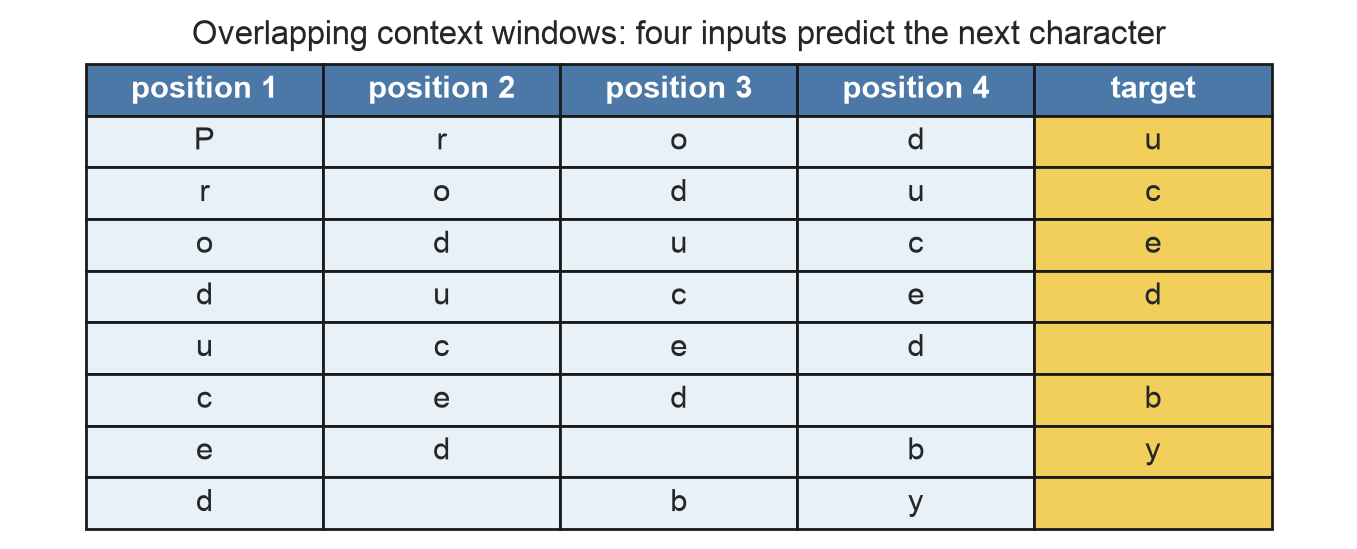

In [5]:
# A compact visual alignment: each row is one overlapping training example.
preview_start = example_number
preview_count = 8
preview_contexts = train_contexts[preview_start : preview_start + preview_count]
preview_targets = train_targets[preview_start : preview_start + preview_count]

fig, ax = plt.subplots(figsize=(8.5, 2.7))
ax.axis("off")
rows = []
for context, target in zip(preview_contexts, preview_targets):
    rows.append([*list(decode(context)), decode([target])])

table = ax.table(
    cellText=rows,
    colLabels=["position 1", "position 2", "position 3", "position 4", "target"],
    cellLoc="center",
    loc="center",
    colWidths=[0.18] * 5,
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.55)
for (row, column), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#4c78a8")
        cell.get_text().set_color("white")
        cell.get_text().set_weight("bold")
    elif column == 4:
        cell.set_facecolor("#f2cf5b")
    else:
        cell.set_facecolor("#e8f1f8")
ax.set_title("Overlapping context windows: four inputs predict the next character", pad=16)
plt.show()

The first dimension is the number of examples. The second dimension is the time axis inside each example. A mini-batch therefore has shape `(batch, time)`, not one long undifferentiated vector. Keeping this distinction visible will matter even more when attention is introduced.

In [6]:
BATCH_SIZE = 128

def sample_batch(contexts, targets, batch_size, generator):
    """Select a reproducible random mini-batch from prebuilt examples."""
    indices = torch.randint(0, len(contexts), (batch_size,), generator=generator)
    return contexts[indices].to(DEVICE), targets[indices].to(DEVICE)

batch_generator = torch.Generator().manual_seed(SEED)
batch_contexts, batch_targets = sample_batch(
    train_contexts, train_targets, BATCH_SIZE, batch_generator
)
print("batch contexts:", tuple(batch_contexts.shape), "= (batch, time)")
print("batch targets:", tuple(batch_targets.shape), "= (batch,)")
print("one example:", decode(batch_contexts[0].cpu()), "->", decode([batch_targets[0].cpu()]))

batch contexts: (128, 4) = (batch, time)
batch targets: (128,) = (batch,)
one example: ound -> a


## 4. A baseline that only sees one character

The earlier project already gives us a useful reference: a smoothed conditional table for `P(next | current)`. We evaluate it on the validation transitions. The context model must beat this baseline to justify its extra parameters.

In [7]:
def smoothed_bigram_probabilities(stream, vocabulary_size, smoothing=1.0):
    counts = torch.full((vocabulary_size, vocabulary_size), smoothing, dtype=torch.float64)
    counts.index_put_(
        (stream[:-1], stream[1:]),
        torch.ones(len(stream) - 1, dtype=torch.float64),
        accumulate=True,
    )
    return counts / counts.sum(dim=1, keepdim=True)

def evaluate_bigram(probabilities, contexts, targets):
    current_ids = contexts[:, -1]
    target_probabilities = probabilities[current_ids, targets].clamp_min(1e-12)
    return float(-target_probabilities.log().mean())

bigram_probabilities = smoothed_bigram_probabilities(train_ids, len(characters))
bigram_validation_loss = evaluate_bigram(
    bigram_probabilities, validation_contexts, validation_targets
)
print(f"bigram validation loss: {bigram_validation_loss:.3f}")
print(f"bigram perplexity: {math.exp(bigram_validation_loss):.2f}")

bigram validation loss: 2.447
bigram perplexity: 11.55


## 5. A small feed-forward context model

Each character ID is mapped to an embedding vector. The four embedding vectors are concatenated, passed through a nonlinear layer, and converted to one logit per possible next character. The model does not use attention yet; it reads the fixed four positions in parallel.

If the vocabulary has `V` characters, the output has shape `(batch, V)`. Cross-entropy applies the softmax internally and compares those logits with one target ID per example.

In [8]:
class ContextLanguageModel(nn.Module):
    """Predict the next character from a fixed-length character context."""

    def __init__(self, vocabulary_size, context_length, embedding_size=32, hidden_size=128):
        super().__init__()
        self.context_length = context_length
        self.embedding = nn.Embedding(vocabulary_size, embedding_size)
        self.network = nn.Sequential(
            nn.Linear(context_length * embedding_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, vocabulary_size),
        )

    def forward(self, context_ids, targets=None):
        embeddings = self.embedding(context_ids)
        flattened = embeddings.reshape(context_ids.shape[0], -1)
        logits = self.network(flattened)
        loss = None if targets is None else F.cross_entropy(logits, targets)
        return logits, loss

model = ContextLanguageModel(
    vocabulary_size=len(characters),
    context_length=CONTEXT_LENGTH,
).to(DEVICE)
print(model)
print("trainable parameters:", sum(parameter.numel() for parameter in model.parameters()))

ContextLanguageModel(
  (embedding): Embedding(93, 32)
  (network): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=93, bias=True)
  )
)
trainable parameters: 31485


In [9]:
# Trace the forward pass with the actual batch.
with torch.no_grad():
    embeddings = model.embedding(batch_contexts)
    flattened = embeddings.reshape(BATCH_SIZE, -1)
    logits, batch_loss = model(batch_contexts, batch_targets)

print("input IDs:", tuple(batch_contexts.shape))
print("embeddings:", tuple(embeddings.shape), "= (batch, time, embedding)")
print("flattened embeddings:", tuple(flattened.shape))
print("logits:", tuple(logits.shape), "= (batch, vocabulary)")
print("loss:", f"{batch_loss.item():.3f}")
assert logits.shape == (BATCH_SIZE, len(characters))

input IDs: (128, 4)
embeddings: (128, 4, 32) = (batch, time, embedding)
flattened embeddings: (128, 128)
logits: (128, 93) = (batch, vocabulary)
loss: 4.606


## 6. Train and measure

The training loop samples windows from the training stream, computes cross-entropy, backpropagates through the embeddings and linear layers, and updates the parameters with Adam. We record the same loss on held-out windows after each evaluation interval. The validation curve is the evidence that the wider context generalizes beyond memorizing the training transitions.

In [10]:
def estimate_loss(model, contexts, targets, batches=40):
    model.eval()
    losses = []
    generator = torch.Generator().manual_seed(SEED + 1)
    with torch.no_grad():
        for _ in range(batches):
            batch_contexts, batch_targets = sample_batch(
                contexts, targets, BATCH_SIZE, generator
            )
            _, loss = model(batch_contexts, batch_targets)
            losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)
train_losses, validation_losses, steps = [], [], []
training_generator = torch.Generator().manual_seed(SEED + 2)

for step in range(1, 1801):
    batch_contexts, batch_targets = sample_batch(
        train_contexts, train_targets, BATCH_SIZE, training_generator
    )
    _, loss = model(batch_contexts, batch_targets)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if step == 1 or step % 100 == 0:
        steps.append(step)
        train_losses.append(estimate_loss(model, train_contexts, train_targets))
        validation_losses.append(estimate_loss(model, validation_contexts, validation_targets))

print(f"final train loss: {train_losses[-1]:.3f}")
print(f"final validation loss: {validation_losses[-1]:.3f}")
print(f"final validation perplexity: {math.exp(validation_losses[-1]):.2f}")

final train loss: 1.842
final validation loss: 1.873
final validation perplexity: 6.51


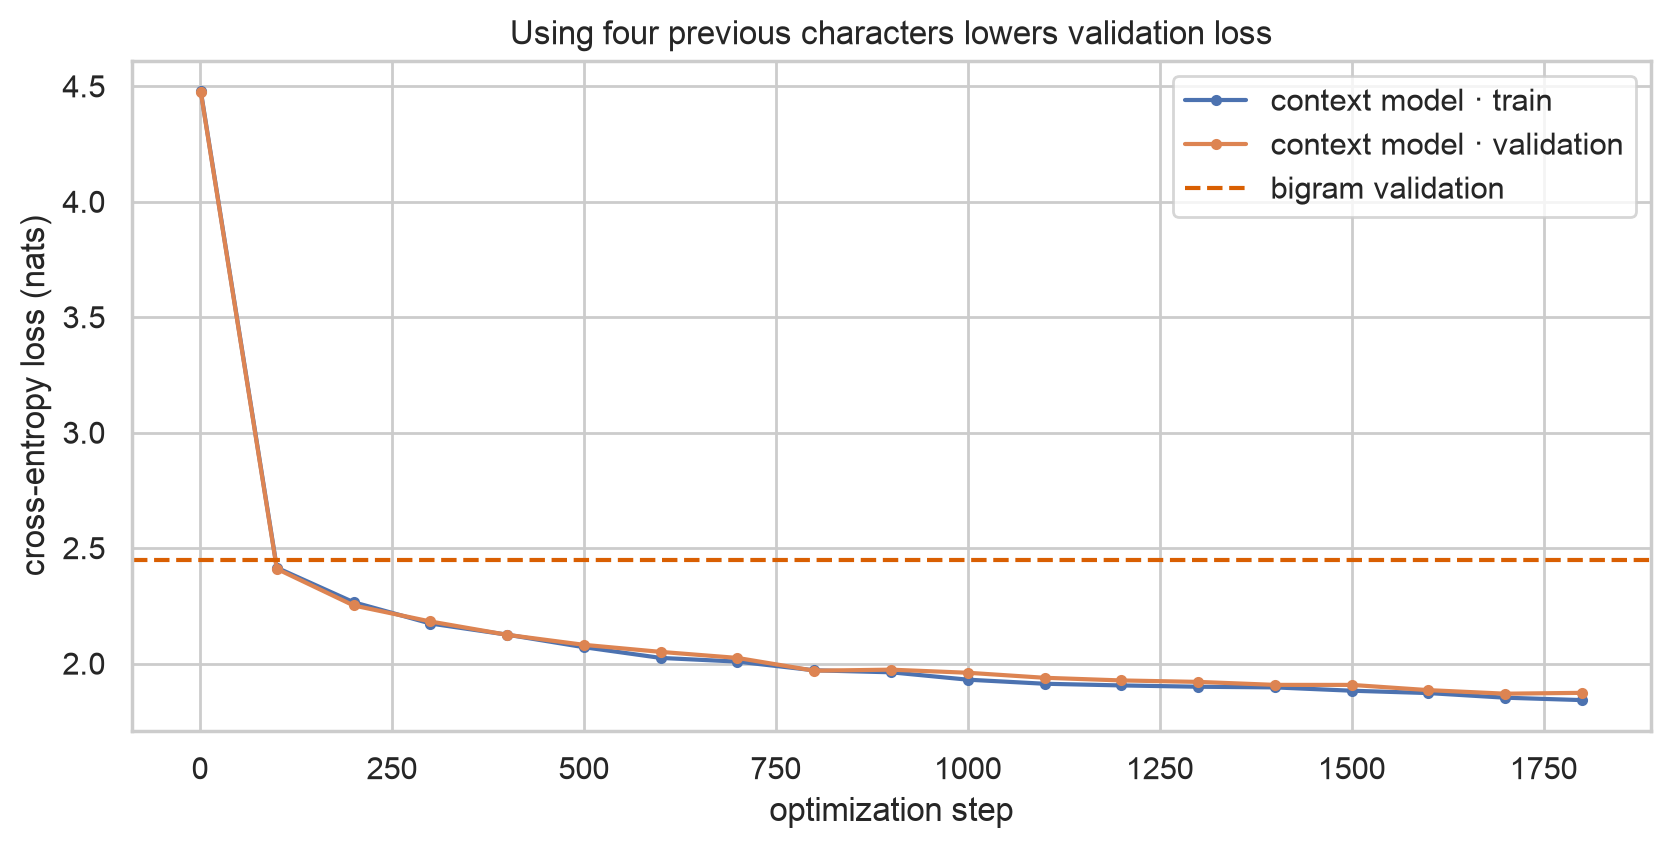

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(steps, train_losses, marker="o", ms=3, label="context model · train")
ax.plot(steps, validation_losses, marker="o", ms=3, label="context model · validation")
ax.axhline(bigram_validation_loss, color="#d95f02", ls="--", label="bigram validation")
ax.set(
    title="Using four previous characters lowers validation loss",
    xlabel="optimization step",
    ylabel="cross-entropy loss (nats)",
)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

The comparison is deliberately modest. The context model has more parameters and sees four positions, so a lower loss is expected. What matters is the mechanism: the model can condition on combinations such as `" th"` or `"ing"`, rather than treating every occurrence of `g` as having the same future. It still has no memory beyond four characters.

## 7. Generate from the learned distribution

At inference time the model returns logits for the next character. Temperature changes only the sampling distribution; it does not retrain the model. We keep the random seed fixed so the comparison is about temperature rather than a different random draw.

In [12]:
@torch.no_grad()
def generate_text(model, start_text, number_of_characters, temperature=1.0, seed=0):
    if temperature <= 0:
        raise ValueError("temperature must be positive")
    model.eval()
    generated = list(start_text)
    generator = torch.Generator(device=DEVICE).manual_seed(seed)

    for _ in range(number_of_characters):
        context_text = "".join(generated[-CONTEXT_LENGTH:])
        if len(context_text) < CONTEXT_LENGTH:
            context_text = " " * (CONTEXT_LENGTH - len(context_text)) + context_text
        context_ids = encode(context_text).unsqueeze(0).to(DEVICE)
        logits, _ = model(context_ids)
        probabilities = torch.softmax(logits[0] / temperature, dim=-1)
        next_id = torch.multinomial(probabilities, 1, generator=generator).item()
        generated.append(id_to_character[next_id])

    return "".join(generated)

for temperature in (0.55, 0.85, 1.15):
    sample = generate_text(model, "The ", 180, temperature=temperature, seed=SEED)
    print(f"\nTemperature {temperature}:\n{sample}")


Temperature 0.55:
The suee in the fient mome could to be warkend the in a see skor a sene. I had sute of the are the gould not my fire the wonle fear the pouse in a mortoon stie unto the to the sees to 

Temperature 0.85:
The skeed ming of the
greate that we stow we have ming are alkory
man, thip upon the maicil a grent. I
stratime fire the wonle fecrutthe ourse sual,
whoch itseed a been the Rad an he w

Temperature 1.15:
The skeeciedderrew ther
but plately botcityed at rimon are is or mann, terpeuues terom in  arous
not this hould firs.

IlConjoüu—grutfhing heage auve toon stie un rife sooml. I was now


## What this experiment establishes

- A context window creates many overlapping `(context, target)` examples from one stream.
- A batch keeps the time axis explicit: `(batch, time)`.
- Concatenating several character embeddings lets a small network model short patterns that a bigram table cannot see.
- Cross-entropy gives one training objective for both the baseline comparison and the PyTorch model.

## What it does not establish

This is not yet a Transformer. The context length is fixed, the four positions are flattened before prediction, and the model has no learned way to route information between positions. Increasing the window requires changing the input layer. The next notebook will address tokenization and batching more explicitly; then self-attention will replace this fixed wiring with content-dependent information routing.